In [17]:
import numpy as np
import pandas as pd

In [18]:
data = pd.read_csv('segmentation.csv')

df = data.copy()

df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,52,3,30,120,5.234,10.432,0.0,NBA045,13.1


In [19]:
df = df.drop(['Address', 'Customer Id'], axis = 1)
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,52,3,30,120,5.234,10.432,0.0,13.1


In [20]:
from sklearn.preprocessing import StandardScaler

x = df.values[:, 0:]

scaler = StandardScaler()

x_normalize = scaler.fit_transform(x)

In [21]:
from sklearn.cluster import KMeans

k_means = KMeans(init = "k-means++", n_clusters = 3, n_init = 15)

k_means.fit(x_normalize)

labels = k_means.labels_

df['Class'] = labels

print()
print()

df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,Class
0,41,2,6,19,0.124,1.073,0.0,6.3,1
1,47,1,26,100,4.582,8.218,0.0,12.8,0
2,33,2,10,57,6.111,5.802,1.0,20.9,0
3,29,2,4,19,0.681,0.516,0.0,6.3,1
4,52,3,30,120,5.234,10.432,0.0,13.1,0


Text(0.5, 0, 'Age')

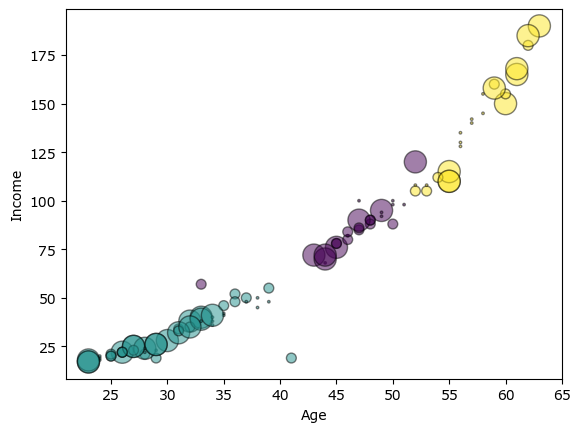

In [22]:
import matplotlib.pyplot as plt

area = np.pi * (x[:, 1])**4

plt.scatter(x[:, 0], x[:, 3], c = labels, alpha = 0.5, edgecolor = 'k', s = area)

plt.ylabel('Income')
plt.xlabel('Age')

In [24]:
df.groupby('Class').mean()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Class,,,,,,,,
0,46.653846,1.961538,20.230769,85.807692,5.825538,6.420538,0.192308,14.323077
1,30.580000,2.000000,6.740000,31.340000,1.467020,1.180660,0.000000,7.418000
2,57.250000,2.000000,32.708333,139.958333,10.123958,13.910000,1.000000,17.070833
